# EDA – CHRONO24 PRICE PREDICTION MODELS

# Load Data and Inspect

In [116]:
!pip install kagglehub -q

In [117]:

import kagglehub
import pandas as pd
import numpy as np
import warnings
import os
import re


pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

path = kagglehub.dataset_download("philmorekoung11/luxury-watch-listings")
print(f"Dataset downloaded to: {path}")

df = pd.read_csv(f"{path}/Watches.csv")

print(f"Shape: {df.shape}")
print(f"\nFull duplicates: {df.duplicated().sum()}")
df.head()

Using Colab cache for faster access to the 'luxury-watch-listings' dataset.
Dataset downloaded to: /kaggle/input/luxury-watch-listings
Shape: (284491, 14)

Full duplicates: 0


,Unnamed: 0,name,price,brand,model,ref,mvmt,casem,bracem,yop,cond,sex,size,condition
0,0,Audemars Piguet Royal Oak Offshore Chronograph\n'25th Anniversary',"$43,500",Audemars Piguet,Royal Oak Offshore Chronograph,26237ST.OO.1000ST.01,NaN,NaN,NaN,2019,Unworn,Men's watch/Unisex,42 mm,NaN
1,1,Audemars Piguet Royal Oak Selfwinding\n39mm Blue Dial,"$71,500",Audemars Piguet,Royal Oak Selfwinding,15300ST.OO.1220ST.02,NaN,NaN,NaN,2012,Very good,Men's watch/Unisex,39 mm,NaN
2,2,Audemars Piguet Royal Oak Chronograph\nBlue Dial - BV Limited Edition 10 Dlc - Pvd,"$79,191",Audemars Piguet,Royal Oak Chronograph,26331ST,Automatic,Steel,Steel,Unknown,Unworn,NaN,41 mm,NaN
3,3,Audemars Piguet Royal Oak Chronograph\nSelfwinding Chronograph Blue Dial,"$108,000",Audemars Piguet,Royal Oak Chronograph,26715ST.OO.1356ST.01,Automatic,Steel,Steel,2022 (Approximation),New,Men's watch/Unisex,38 mm,NaN
4,4,Audemars Piguet Royal Oak Offshore Chronograph\nCronografo 42mm Panda Dial 26170STOO1000ST01,"$27,500",Audemars Piguet,Royal Oak Offshore Chronograph,26170ST.OO.1000ST.01,Automatic,Steel,Steel,Unknown,Very good,Men's watch/Unisex,42 x 54 mm,NaN


In [118]:
for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].dropna().unique()[:10])


--- Unnamed: 0 ---
[0 1 2 3 4 5 6 7 8 9]

--- name ---
["Audemars Piguet Royal Oak Offshore Chronograph\n'25th Anniversary'"
 'Audemars Piguet Royal Oak Selfwinding\n39mm Blue Dial'
 'Audemars Piguet Royal Oak Chronograph\nBlue Dial - BV Limited Edition 10 Dlc - Pvd'
 'Audemars Piguet Royal Oak Chronograph\nSelfwinding Chronograph Blue Dial'
 'Audemars Piguet Royal Oak Offshore Chronograph\nCronografo 42mm Panda Dial 26170STOO1000ST01'
 'Audemars Piguet Royal Oak Offshore Diver\n2018 Unworn Royal Oak Offshore Diver (Limit 200pics)'
 'Audemars Piguet Royal Oak Offshore Diver Chronograph\n26703ST.OO.A051CA.01'
 'Audemars Piguet Royal Oak Offshore Chronograph\n26470IO.OO.A006CA.01'
 'Audemars Piguet Royal Oak Dual Time\n26120ST.OO.1220ST.03'
 'Audemars Piguet Royal Oak Offshore Chronograph\n26401.RO.OO.A002.CA.01']

--- price ---
['$43,500' '$71,500' '$79,191' '$108,000' '$27,500' '$41,000' '$37,800'
 '$32,182' '$36,473' '$35,000']

--- brand ---
['Audemars Piguet' 'Cartier' 'Tudor' 'Bre

In [119]:
from datetime import datetime

CURRENT_YEAR = datetime.now().year

# Cleaning

In [120]:
print(f"Shape before cleaning: {df.shape}")

df = df.drop(columns=['Unnamed: 0'])

df['price'] = df['price'].str.replace(r'[\$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])
df = df[df['price'] > 0]

df['condition'] = df['condition'].fillna(df['cond'])
df = df.drop(columns=['cond'])

df['yop_approx'] = df['yop'].str.contains('Approximation', na=False).astype(int)
df['yop'] = pd.to_numeric(df['yop'].str.extract(r'(\d{4})')[0], errors='coerce')

df['size_mm'] = pd.to_numeric(df['size'].str.extract(r'(\d+\.?\d*)')[0], errors='coerce')
df = df.drop(columns=['size'])

for col in ['sex', 'condition', 'model', 'brand', 'mvmt']:
    df[col] = df[col].fillna('Unknown')

df = df.drop_duplicates(subset=['name', 'ref', 'price', 'brand'], keep='first')

print(f"Shape after cleaning: {df.shape}")
print(f"\nMissing values (%):\n{(df.isnull().sum() / len(df) * 100).round(2)}")
print(f"\nPrice stats:\n{df['price'].describe()}")
print(f"\nyop stats:\n{df['yop'].describe()}")
print(f"\nsize_mm stats:\n{df['size_mm'].describe()}")

Shape before cleaning: (284491, 14)
Shape after cleaning: (247823, 13)

Missing values (%):
name          21.44
price          0.00
brand          0.00
model          0.00
ref           15.79
mvmt           0.00
casem         58.59
bracem        62.34
yop           34.34
sex            0.00
condition      0.00
yop_approx     0.00
size_mm        8.31
dtype: float64

Price stats:
count    2.478230e+05
mean     1.864181e+04
std      6.775256e+04
min      1.000000e+01
25%      2.850000e+03
50%      6.517000e+03
75%      1.568800e+04
max      9.000000e+06
Name: price, dtype: float64

yop stats:
count    162719.000000
mean       2009.034065
std          20.881424
min        1559.000000
25%        2003.000000
50%        2020.000000
75%        2023.000000
max        2024.000000
Name: yop, dtype: float64

size_mm stats:
count    2.272180e+05
mean     3.801021e+08
std      2.867050e+10
min      0.000000e+00
25%      3.600000e+01
50%      4.000000e+01
75%      4.200000e+01
max      2.724317e+12
N

In [121]:
key_cols = ['price', 'casem', 'bracem', 'ref']

before_rows = len(df)
df = df.copy()
df = df.dropna(subset=key_cols)

print(f"Rows before: {before_rows}")
print(f"Rows after dropping rows with any gap in key columns: {len(df)}")
print(f"Rows removed: {before_rows - len(df)}")

Rows before: 247823
Rows after dropping rows with any gap in key columns: 85695
Rows removed: 162128


# Anomaly Detection and Treatment

In [122]:
list(df.columns)

['name',
 'price',
 'brand',
 'model',
 'ref',
 'mvmt',
 'casem',
 'bracem',
 'yop',
 'sex',
 'condition',
 'yop_approx',
 'size_mm']

In [123]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

df.loc[(df['size_mm'] < 15) | (df['size_mm'] > 60), 'size_mm'] = np.nan
df.loc[(df['yop'] < 1900) | (df['yop'] > 2026), 'yop'] = np.nan

price_low, price_high = df['price'].quantile([0.005, 0.995])
before_rows = len(df)
df = df[(df['price'] >= price_low) & (df['price'] <= price_high)]
print(f"Rows removed by price quantile clipping: {before_rows - len(df)}")
print(f"Price range kept: {price_low:.0f} - {price_high:.0f}")

df['log_price'] = np.log1p(df['price'])

anomaly_report = {}
for col in ['log_price', 'yop', 'size_mm']:
    low, high = iqr_bounds(df[col].dropna())
    n_low = (df[col] < low).sum()
    n_high = (df[col] > high).sum()
    anomaly_report[col] = {'lower_bound': low, 'upper_bound': high, 'n_below': n_low, 'n_above': n_high}

anomaly_df = pd.DataFrame(anomaly_report).T
print("\nIQR anomaly bounds (post-clipping, log_price used for price):\n", anomaly_df)

skew = df[['price', 'log_price', 'yop', 'size_mm']].skew().sort_values(ascending=False)
print(f"\nSkewness:\n{skew}")

print(f"\nFinal shape: {df.shape}")
print(f"\nMissing values after anomaly treatment:\n{df[['price', 'yop', 'size_mm']].isnull().sum()}")

Rows removed by price quantile clipping: 857
Price range kept: 267 - 246000

IQR anomaly bounds (post-clipping, log_price used for price):
            lower_bound  upper_bound  n_below  n_above
log_price     5.847333     12.11675    320.0    327.0
yop        1993.000000   2041.00000   5894.0      0.0
size_mm      27.000000     51.00000   3884.0     66.0

Skewness:
price        3.926542
log_price    0.092008
size_mm     -1.247495
yop         -2.110283
dtype: float64

Final shape: (84838, 14)

Missing values after anomaly treatment:
price          0
yop        25670
size_mm     3039
dtype: int64


In [124]:
before_rows = len(df)

for col in ['log_price', 'yop', 'size_mm']:
    low, high = anomaly_df.loc[col, 'lower_bound'], anomaly_df.loc[col, 'upper_bound']
    df = df[(df[col] >= low) & (df[col] <= high)]

print(f"Rows removed by IQR (all 3 columns): {before_rows - len(df)}")
print(f"\nFinal shape: {df.shape}")
print(f"\nSkewness after outlier removal:\n{df[['price', 'log_price', 'yop', 'size_mm']].skew().sort_values(ascending=False)}")

Rows removed by IQR (all 3 columns): 35646

Final shape: (49192, 14)

Skewness after outlier removal:
price        3.007589
log_price   -0.059026
size_mm     -1.054848
yop         -1.726571
dtype: float64


In [125]:
print(f"\nFinal shape: {df.shape}")
print(f"\nBrand counts after filtering:\n{df['brand'].value_counts()}")
print(f"\nCondition counts after filtering:\n{df['condition'].value_counts()}")


Final shape: (49192, 14)

Brand counts after filtering:
brand
Rolex                  18383
Omega                   6129
Breitling               3620
Hublot                  2803
TAG Heuer               2779
Longines                2739
Cartier                 1710
IWC                     1569
Patek Philippe          1513
Tudor                   1351
Audemars Piguet         1327
Oris                    1160
Panerai                 1032
Seiko                   1027
Zenith                   811
Jaeger-LeCoultre         589
Vacheron Constantin      413
A. Lange & Söhne         180
Sinn                      36
Richard Mille             18
NOMOS                      2
Rado                       1
Name: count, dtype: int64

Condition counts after filtering:
condition
New          20933
Very good    16684
Unworn        8475
Good          2624
Unknown        234
Fair           233
Poor             9
Name: count, dtype: int64


In [126]:
ans = df[(df['brand'] == "Seiko" ) & (df['model'] == "Prospex" )]

ans[["name", "model", "ref", "price"]].head(10)

,name,model,ref,price
224329,Seiko Prospex\nMen's SRP777K1/SRPE93K1 Prospex Turtle Auto,Prospex,SRPE93K1,413.0
224330,Seiko Prospex\nMen's SRPD25K1 Prospex Monster Watch,Prospex,SRPD25K1,431.0
224332,Seiko Prospex\nMen's SRPH11K1 Prospex Samurai Lt.Ed. Date Watch,Prospex,SRPH11K1,516.0
224334,Seiko Prospex\nMen's SRPE37K1 Prospex Samurai King Auto,Prospex,SRPE37K1,585.0
224341,Seiko Prospex\nMen's SPB185J1 Prospex Black Dial Watch,Prospex,SPB185J1,1138.0
224360,Seiko Prospex\nSLA065J1 Prospex Mare Save the Ocean Limited ED 1965,Prospex,SLA065J1,3116.0
224370,Seiko Prospex\nS23626J1 „Golden Tuna”,Prospex,S23626J1,3091.0
224386,Seiko Prospex\nMen's SNR031J1 Prospex LX Line Spring Drive,Prospex,SNR031J1,5803.0
224389,Seiko Prospex\nMen's SPB243J1 Prospex Auto Watch,Prospex,SPB243J1,811.0
224394,Seiko Prospex\nMen's SLA039J1 Prospex 55th Anniversary Lt.Ed Watch,Prospex,SLA039J1,6429.0


In [127]:
new_df = df.copy()

ref_counts = new_df['ref'].value_counts()
rows_covered = new_df['ref'].map(ref_counts)

for threshold in [2, 3, 5, 10]:
    n_rows = (rows_covered >= threshold).sum()
    print(f"Refs with >={threshold} listings cover {n_rows} rows ({n_rows/len(new_df)*100:.1f}%)")

seiko = new_df[new_df['brand'] == 'Seiko']
seiko_rows_covered = seiko['ref'].map(seiko['ref'].value_counts())
print(f"\nSeiko rows covered by refs with >=3 listings: {(seiko_rows_covered >= 3).sum()} / {len(seiko)} ({(seiko_rows_covered >= 3).sum()/len(seiko)*100:.1f}%)")

Refs with >=2 listings cover 42534 rows (86.5%)
Refs with >=3 listings cover 38238 rows (77.7%)
Refs with >=5 listings cover 31616 rows (64.3%)
Refs with >=10 listings cover 22640 rows (46.0%)

Seiko rows covered by refs with >=3 listings: 555 / 1027 (54.0%)


In [128]:
print(f"Unique refs: {new_df['ref'].nunique()} across {len(new_df)} rows")
print(f"Refs appearing once: {(new_df['ref'].value_counts() == 1).sum()}")
print(f"Refs appearing >=3 times: {(new_df['ref'].value_counts() >= 3).sum()}")

seiko_refs = new_df[new_df['brand'] == 'Seiko']['ref'].value_counts()
print(f"\nSeiko: {len(seiko_refs)} unique refs, {(seiko_refs >= 3).sum()} with >=3 listings")
print(seiko_refs.head(10))

Unique refs: 12823 across 49192 rows
Refs appearing once: 6658
Refs appearing >=3 times: 4017

Seiko: 523 unique refs, 138 with >=3 listings
ref
SSK005K1    8
SSK001K1    7
SRPH75K1    7
SPB103J1    7
SPB101J1    6
SPB147J1    6
SRPF03K1    6
SPB167J1    6
SPB221J1    6
SSA453J1    6
Name: count, dtype: int64


# EDA

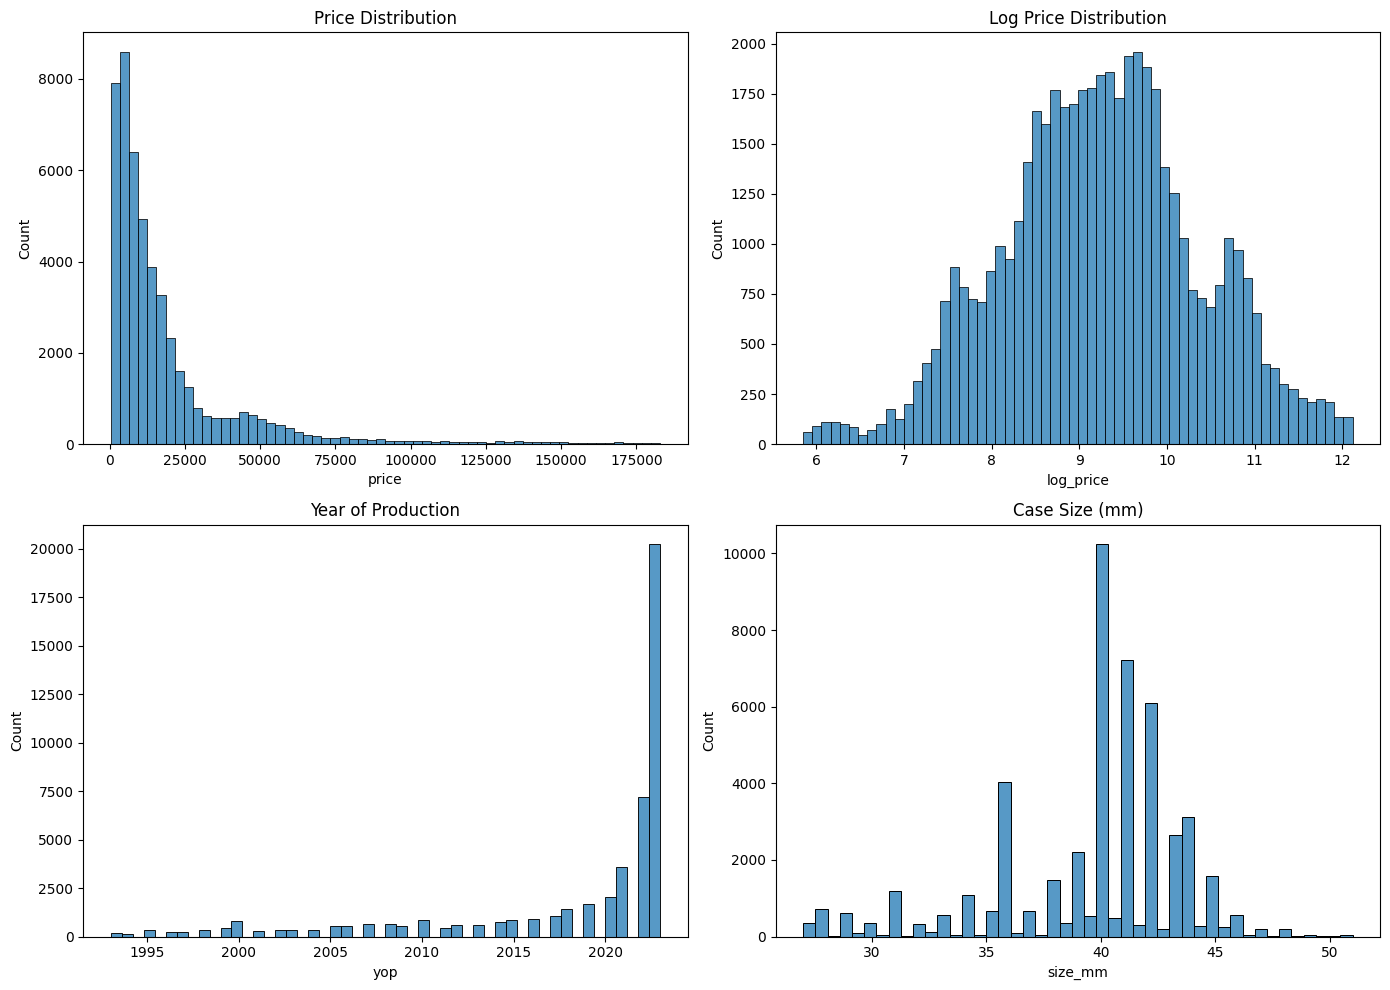

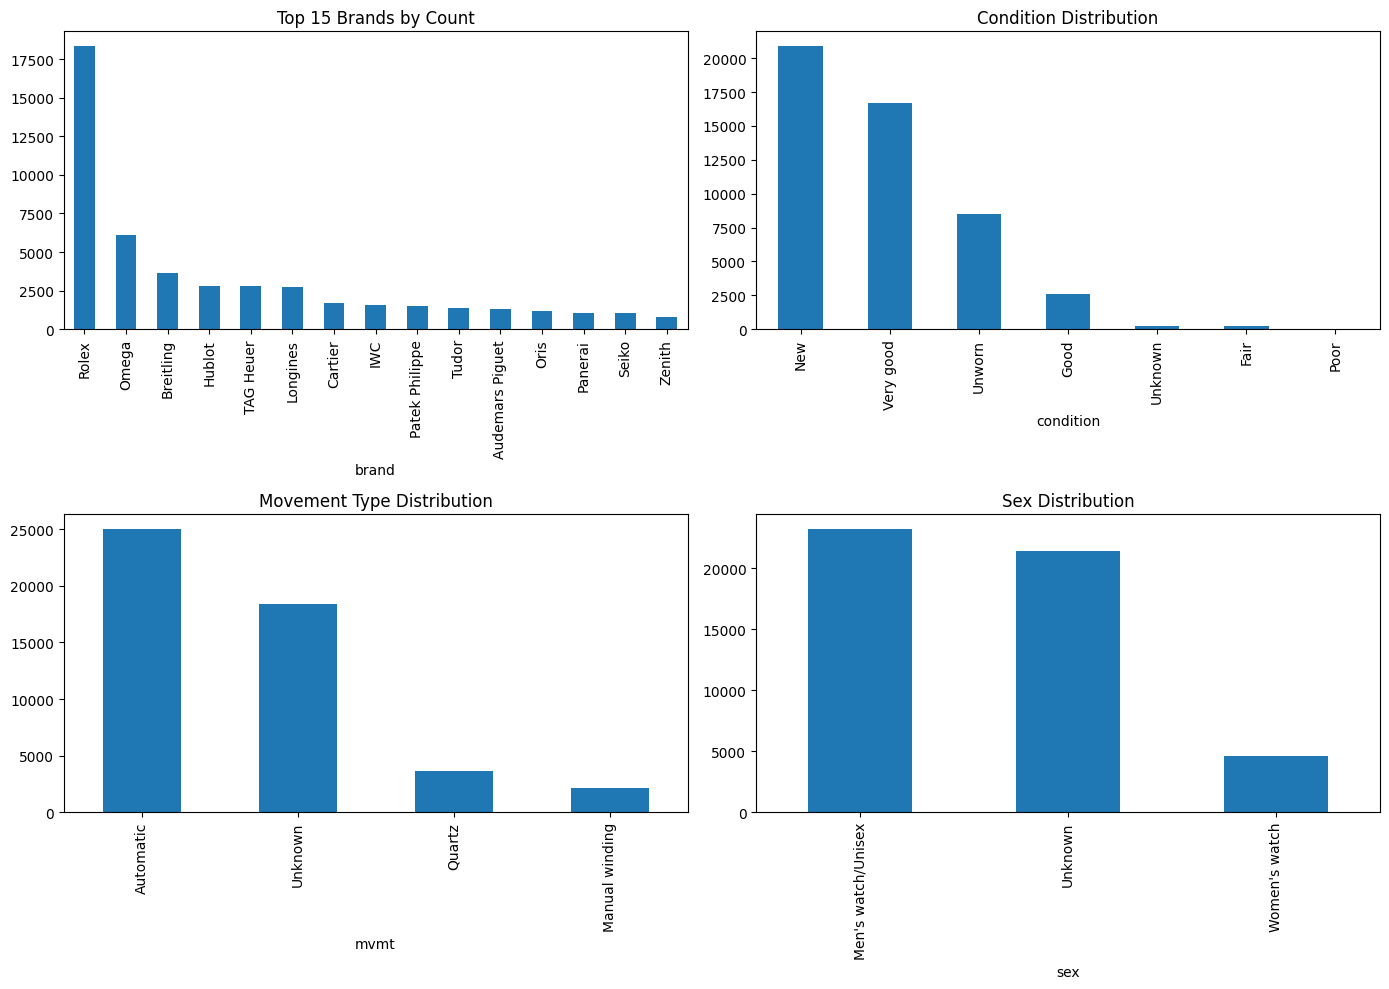

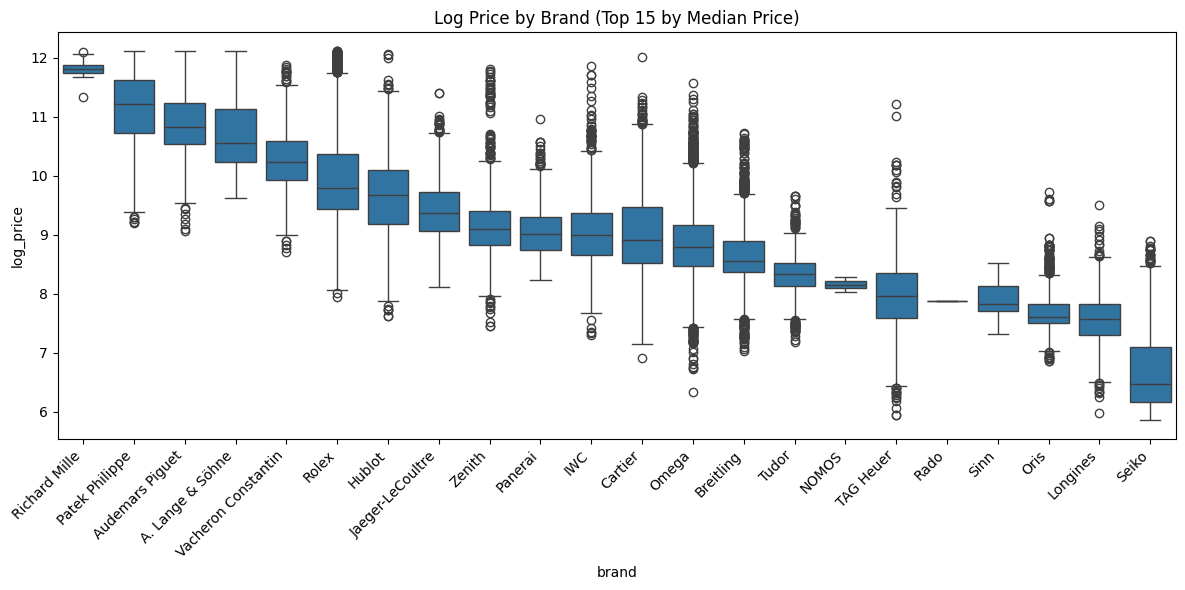

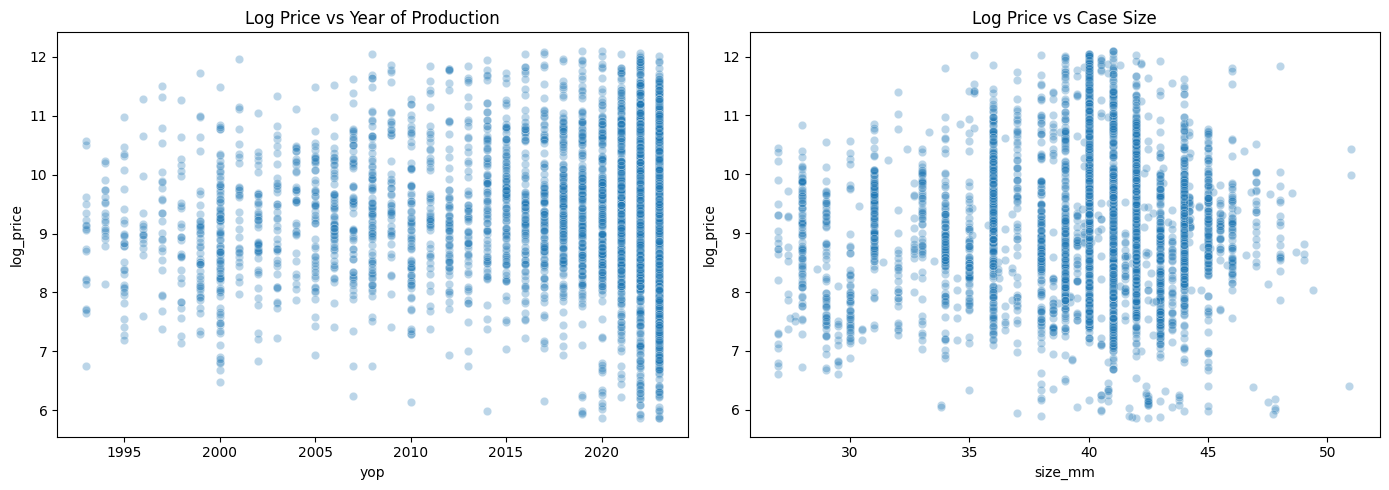

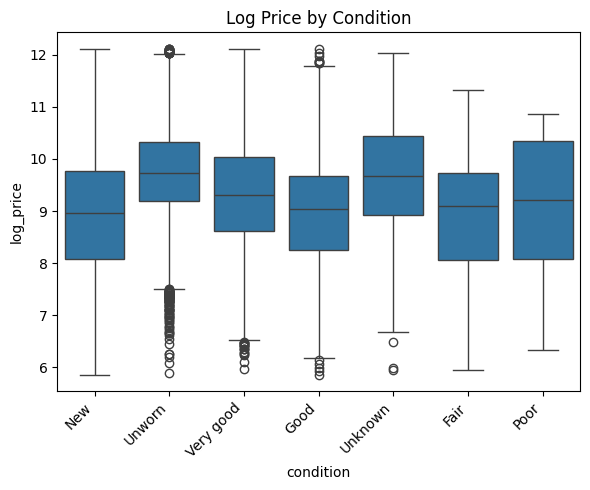

In [129]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['price'], bins=60, ax=axes[0, 0])
axes[0, 0].set_title('Price Distribution')
sns.histplot(df['log_price'], bins=60, ax=axes[0, 1])
axes[0, 1].set_title('Log Price Distribution')
sns.histplot(df['yop'].dropna(), bins=50, ax=axes[1, 0])
axes[1, 0].set_title('Year of Production')
sns.histplot(df['size_mm'].dropna(), bins=45, ax=axes[1, 1])
axes[1, 1].set_title('Case Size (mm)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df['brand'].value_counts().head(15).plot(kind='bar', ax=axes[0, 0])
axes[0, 0].set_title('Top 15 Brands by Count')
df['condition'].value_counts().plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Condition Distribution')
df['mvmt'].value_counts().plot(kind='bar', ax=axes[1, 0])
axes[1, 0].set_title('Movement Type Distribution')
df['sex'].value_counts().plot(kind='bar', ax=axes[1, 1])
axes[1, 1].set_title('Sex Distribution')
plt.tight_layout()
plt.show()

top_brands = df.groupby('brand')['price'].median().sort_values(ascending=False).head(25).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df['brand'].isin(top_brands)], x='brand', y='log_price', order=top_brands)
plt.xticks(rotation=45, ha='right')
plt.title('Log Price by Brand (Top 15 by Median Price)')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df.sample(min(5000, len(df))), x='yop', y='log_price', alpha=0.3, ax=axes[0])
axes[0].set_title('Log Price vs Year of Production')
sns.scatterplot(data=df.sample(min(5000, len(df))), x='size_mm', y='log_price', alpha=0.3, ax=axes[1])
axes[1].set_title('Log Price vs Case Size')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='condition', y='log_price')
plt.xticks(rotation=45, ha='right')
plt.title('Log Price by Condition')
plt.tight_layout()
plt.show()

In [130]:
import re
from collections import Counter

sample_df = df[['name', 'brand', 'model']].dropna(subset=['name']).head(50000)

def remove_brand_model(row):
    text = row['name'].replace('\n', ' ')
    for val in [row['brand'], row['model']]:
        if pd.notnull(val):
            text = re.sub(re.escape(val), '', text, flags=re.IGNORECASE)
    return text

cleaned = sample_df.apply(remove_brand_model, axis=1)

words = cleaned.str.split().sum()
words = [w.lower().strip('.,()-\'"') for w in words]
words = [w for w in words if w and not any(c.isdigit() for c in w)]
word_counts = Counter(words)

top_25 = pd.DataFrame(word_counts.most_common(25), columns=['word', 'count'])
print(top_25)

           word  count
0     automatic   2909
1         watch   2907
2   chronograph   2811
3          dial   2359
4         steel   2169
5          gold   1949
6            mm   1914
7        master   1794
8   chronometer   1784
9      co-axial   1691
10          box   1537
11        black   1387
12         blue   1230
13       papers   1216
14    stainless    839
15      edition    836
16        white    777
17          new    749
18          set    728
19         full    726
20          ref    705
21           de    670
22         rose    666
23        men's    645
24     titanium    643


In [131]:
import re
from collections import Counter

MATERIAL_LIST = ['steel', 'gold', 'titanium', 'platinum', 'ceramic', 'carbon', 'bronze',
                  'rubber', 'leather', 'rose gold', 'white gold', 'yellow gold', 'silver',
                  'sapphire', 'aluminum', 'aluminium', 'tantalum', 'palladium']

MATERIAL_SUFFIXES = ['steel', 'gold', 'titanium', 'ceramic', 'carbon', 'bronze']

def extract_material(name):
    if not isinstance(name, str):
        return 'unknown'
    text = name.lower()

    for word in text.split():
        for suffix in MATERIAL_SUFFIXES:
            if word.endswith(suffix):
                return suffix

    return 'unknown'

df['material'] = df['name'].apply(extract_material)

material_counts = df['material'].value_counts()
print(material_counts)

material
unknown     43833
steel        2287
gold         1982
titanium      648
ceramic       281
bronze        105
carbon         56
Name: count, dtype: int64


In [132]:
keywords = 'limited|anniversary|edition'
count = df['name'].str.lower().str.contains(keywords, case=False, na=False, regex=True).sum()
print(f"Total mentions: {count}")

Total mentions: 1233


In [133]:
keywords = 'papers|box|full set'
count = df['name'].str.lower().str.contains(keywords, case=False, na=False, regex=True).sum()
print(f"Total mentions: {count}")

Total mentions: 2585


In [134]:
keywords = 'king|royal|luxury|exclusive|elite|prestige'
count = df['name'].str.lower().str.contains(keywords, case=False, na=False, regex=True).sum()
print(f"Total mentions: {count}")

Total mentions: 2559


In [135]:
print(df['condition'].value_counts())
print(df['mvmt'].value_counts())

condition
New          20933
Very good    16684
Unworn        8475
Good          2624
Unknown        234
Fair           233
Poor             9
Name: count, dtype: int64
mvmt
Automatic         25061
Unknown           18419
Quartz             3599
Manual winding     2113
Name: count, dtype: int64


# Feature Engineering

In [136]:
list(df.columns)

['name',
 'price',
 'brand',
 'model',
 'ref',
 'mvmt',
 'casem',
 'bracem',
 'yop',
 'sex',
 'condition',
 'yop_approx',
 'size_mm',
 'log_price',
 'material']

- **name** — List Name - drop, or find sellers tricks
- **price** — Price of Watch
- **brand** — Brand of Watch - transform into separate columns
- **model** — Model of Brand – possiable take: usage of Luxury words, number of words
- **ref** — Reference Number - get info from number or drop
- **mvmt** — Movement Type – transform to separate columns
- **casem** — Case Material – transform to separate columns
- **bracem** — Bracelet Material – transform to separate columns
- **yop** — Year of Production – same
- **sex** — Gender / Sex – transform to separate columns
- **condition** — Condition - make unknown as separate column and rest (from 0 to 5)
- **yop_approx** — Year of Production is Approximate (flag) – 1/0 just flag that watches year is Approximated.
- **size_mm** — Case Size (mm) – as it is.
- **log_price** — Log-Transformed Price – Target.

In [235]:
CONDITION_ORDER = {
    'Incomplete': 0, 'Poor': 1, 'Fair': 2, 'Good': 3,
    'Very good': 4, 'New': 5, 'Unworn': 6,
}

COLOR_HUE = {
    'red': 0, 'orange': 30, 'salmon': 10, 'brown': 25, 'copper': 20, 'bronze': 30,
    'yellow': 55, 'gold': 50, 'champagne': 45, 'khaki': 55, 'olive': 80,
    'green': 120, 'teal': 175, 'blue': 210, 'navy': 220,
    'purple': 280, 'pink': 330, 'burgundy': 350,
}
COLOR_LIGHTNESS = {
    'black': 0.05, 'anthracite': 0.2, 'grey': 0.5, 'gray': 0.5, 'brown': 0.3,
    'burgundy': 0.25, 'navy': 0.2, 'bronze': 0.4, 'copper': 0.45, 'olive': 0.35,
    'red': 0.45, 'purple': 0.35, 'blue': 0.45, 'green': 0.4, 'teal': 0.45,
    'gold': 0.6, 'orange': 0.55, 'yellow': 0.7, 'khaki': 0.65, 'pink': 0.75,
    'salmon': 0.75, 'champagne': 0.85, 'beige': 0.85, 'ivory': 0.92, 'silver': 0.85,
    'white': 0.98,
}
ACHROMATIC = {'black', 'white', 'grey', 'gray', 'silver', 'anthracite', 'ivory', 'beige'}
COLOR_LIST = list(set(COLOR_HUE) | set(COLOR_LIGHTNESS))


import re

def _first_n_alnum(ref, n):
    clean = re.sub(r'[^A-Z0-9]', '', ref)
    return clean[:n] if clean else 'Unknown'


def _first_segments(ref, n):
    parts = [p for p in re.split(r'[.\s/\-]+', ref) if p]
    return '.'.join(parts[:n]) if parts else 'Unknown'


BRAND_REF_RULE = {
    'Rolex':               lambda r: _first_n_alnum(r, 6),
    'Tudor':               lambda r: _first_n_alnum(r, 4),
    'Audemars Piguet':     lambda r: _first_n_alnum(r, 5),
    'Patek Philippe':      lambda r: _first_n_alnum(r, 4),
    'Vacheron Constantin': lambda r: _first_n_alnum(r, 5),
    'Cartier':             lambda r: _first_n_alnum(r, 4),
    'Seiko':               lambda r: _first_n_alnum(r, 4),
    'IWC':                 lambda r: _first_n_alnum(r, 5),
    'Jaeger-LeCoultre':    lambda r: _first_n_alnum(r, 4),
    'Longines':            lambda r: _first_n_alnum(r, 4),
    'Panerai':             lambda r: _first_n_alnum(r, 6),
    'Breitling':           lambda r: _first_n_alnum(r, 4),
    'TAG Heuer':           lambda r: _first_n_alnum(r, 4),
    'Omega':               lambda r: _first_segments(r, 1),
    'Hublot':              lambda r: _first_segments(r, 1),
    'A. Lange & Söhne':    lambda r: _first_segments(r, 1),
    'Zenith':              lambda r: _first_segments(r, 2),
    'Oris':                lambda r: _first_segments(r, 3),
}


def extract_ref_key(ref, brand):
    if not isinstance(ref, str) or not ref.strip():
        return 'Unknown'
    ref = ref.strip().upper()
    rule = BRAND_REF_RULE.get(brand, lambda r: _first_n_alnum(r, 4))
    return rule(ref)


def extract_color(name):
    if not isinstance(name, str):
        return 'unknown'
    text = name.lower()
    for color in COLOR_LIST:
        if re.search(rf'\b{color}\b', text):
            return color
    return 'unknown'


def add_numeric_features(df):
    df['watch_age'] = CURRENT_YEAR - df['yop']
    df['size_mm'] = df['size_mm'].fillna(df.groupby('sex')['size_mm'].transform('median'))
    df['size_mm'] = df['size_mm'].fillna(df['size_mm'].median())

    df['size_mm'] = pd.cut(
        df['size_mm'],
        bins=[0, 34, 38, 40, 42, 44, 46, np.inf],
        labels=['<34', '34-38', '38-40', '40-42', '42-44', '44-46', '46+']
    )

    df['yop'] = df['yop'].fillna(df['yop'].median())
    df['watch_age'] = df['watch_age'].fillna(df['watch_age'].median())
    return df


def add_condition_features(df):
    df['condition_score'] = df['condition'].map(CONDITION_ORDER)
    df['condition_score'] = df['condition_score'].fillna(df['condition_score'].median())
    return df


def add_material_features(df):
    df['same_material'] = (df['casem'] == df['bracem']).astype(int)
    gold_pattern = 'gold|platinum'
    df['precious_case'] = df['casem'].str.contains(gold_pattern, case=False, na=False).astype(int)
    df['precious_brace'] = df['bracem'].str.contains(gold_pattern, case=False, na=False).astype(int)
    return df


def add_name_features(df):
    name_filled = df['name'].fillna('')
    df['name_missing'] = df['name'].isna().astype(int)
    df['has_limited'] = name_filled.str.contains('limited|anniversary|edition|remaster|re-edition', case=False).astype(int)
    df['has_papers'] = name_filled.str.contains('papers|box|full set', case=False).astype(int)
    df['has_wealthy_words'] = name_filled.str.contains('king|royal|luxury|exclusive|elite|prestige', case=False).astype(int)

    name_len = name_filled.str.len()
    df['name_len_bucket'] = pd.cut(
        name_len,
        bins=[-1, 20, 40, 60, 80, 100, np.inf],
        labels=['0-20', '21-40', '41-60', '61-80', '81-100', '100+']
    )
    return df


def add_color_features(df):
    df['color'] = df['name'].apply(extract_color)
    df['color_has_hue'] = df['color'].apply(lambda c: 0 if c in ACHROMATIC or c == 'unknown' else 1)
    hue_deg = df['color'].map(COLOR_HUE).fillna(0)
    df['color_hue_sin'] = np.where(df['color_has_hue'] == 1, np.sin(np.radians(hue_deg)), 0)
    df['color_hue_cos'] = np.where(df['color_has_hue'] == 1, np.cos(np.radians(hue_deg)), 0)
    df['color_lightness'] = df['color'].map(COLOR_LIGHTNESS).fillna(0.5)
    return df


def add_price_history_features(df, rare_brand_threshold=100, min_model_count=3, min_prefix_count=5):
    rare_brands = df['brand'].value_counts()[df['brand'].value_counts() < rare_brand_threshold].index
    df['brand'] = df['brand'].replace(rare_brands, 'Other')

    prefix = df.apply(lambda r: extract_ref_key(r['ref'], r['brand']), axis=1)
    prefix_counts = prefix.value_counts()
    rare_prefixes = prefix_counts[prefix_counts < min_prefix_count].index
    df['ref_prefix'] = prefix.where(~prefix.isin(rare_prefixes), 'Other')

    global_median = df['log_price'].median()

    df['brand_model'] = df['brand'] + '_' + df['model']
    model_stats = df.groupby('brand_model')['log_price'].agg(['median', 'count'])
    reliable_models = model_stats[model_stats['count'] >= min_model_count]['median']
    df['model_median_price'] = df['brand_model'].map(reliable_models).fillna(global_median)

    df['brand_model_prefix'] = df['brand_model'] + '_' + df['ref_prefix']
    prefix_stats = df.groupby('brand_model_prefix')['log_price'].agg(['median', 'count'])
    reliable_prefixes = prefix_stats[prefix_stats['count'] >= min_model_count]['median']
    df['model_prefix_median_price'] = df['brand_model_prefix'].map(reliable_prefixes).fillna(df['model_median_price'])

    return df


raw_cols = ['name', 'price', 'brand', 'model', 'ref', 'mvmt', 'casem', 'bracem',
            'yop', 'sex', 'condition', 'size_mm', 'log_price']

new_df = df[raw_cols].copy()

new_df = add_numeric_features(new_df)
new_df = add_condition_features(new_df)
new_df = add_material_features(new_df)
new_df = add_name_features(new_df)
new_df = add_color_features(new_df)
new_df = add_price_history_features(new_df)

drop_cols = ['name', 'model', 'ref', 'price', 'color', 'yop', 'condition', 'brand_model', 'brand_model_prefix', 'model_median_price']

X = new_df.drop(columns=drop_cols + ['log_price'])
y = new_df['log_price']

category_cols = ['brand', 'mvmt', 'casem', 'bracem', 'sex', 'ref_prefix']

for col in category_cols:
    X[col] = X[col].astype('category')

print(f"new_df shape: {new_df.shape}")
print(f"new_df columns: {new_df.columns.tolist()}")
print(f"\nX shape: {X.shape}")
print(f"Categorical columns (kept as-is, not encoded): {category_cols}")
print(f"Any NaN left: {X.isnull().sum().sum()}")
print(f"\nTop correlations with log_price:\n{new_df[X.select_dtypes(include=np.number).columns.tolist() + ['log_price']].corr()['log_price'].abs().sort_values(ascending=False).head(20)}")

new_df shape: (49192, 33)
new_df columns: ['name', 'price', 'brand', 'model', 'ref', 'mvmt', 'casem', 'bracem', 'yop', 'sex', 'condition', 'size_mm', 'log_price', 'watch_age', 'condition_score', 'same_material', 'precious_case', 'precious_brace', 'name_missing', 'has_limited', 'has_papers', 'has_wealthy_words', 'name_len_bucket', 'color', 'color_has_hue', 'color_hue_sin', 'color_hue_cos', 'color_lightness', 'ref_prefix', 'brand_model', 'model_median_price', 'brand_model_prefix', 'model_prefix_median_price']

X shape: (49192, 22)
Categorical columns (kept as-is, not encoded): ['brand', 'mvmt', 'casem', 'bracem', 'sex', 'ref_prefix']
Any NaN left: 0

Top correlations with log_price:
log_price                    1.000000
model_prefix_median_price    0.959861
precious_case                0.533754
name_missing                 0.461261
precious_brace               0.390610
has_wealthy_words            0.151070
color_hue_sin                0.107519
color_lightness              0.106590
color_

# PREDICTION MODEL

In [237]:
from sklearn.model_selection import train_test_split

for col in category_cols:
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (39353, 22)
Test shape: (9839, 22)


In [238]:
# @title
for col in category_cols:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')
        X_test[col] = X_test[col].astype('category')

model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, n_jobs=-1)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)],
          categorical_feature=[c for c in category_cols if c in X_train.columns],
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])

perm_result = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
perm_importance = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values(ascending=False)
print(perm_importance)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005032 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1437
[LightGBM] [Info] Number of data points in the train set: 39353, number of used features: 22
[LightGBM] [Info] Start training from score 9.240449
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	valid_0's l2: 0.0470588
model_prefix_median_price    1.176106
casem                        0.056449
brand                        0.049036
ref_prefix                   0.013409
condition_score              0.009770
watch_age                    0.008

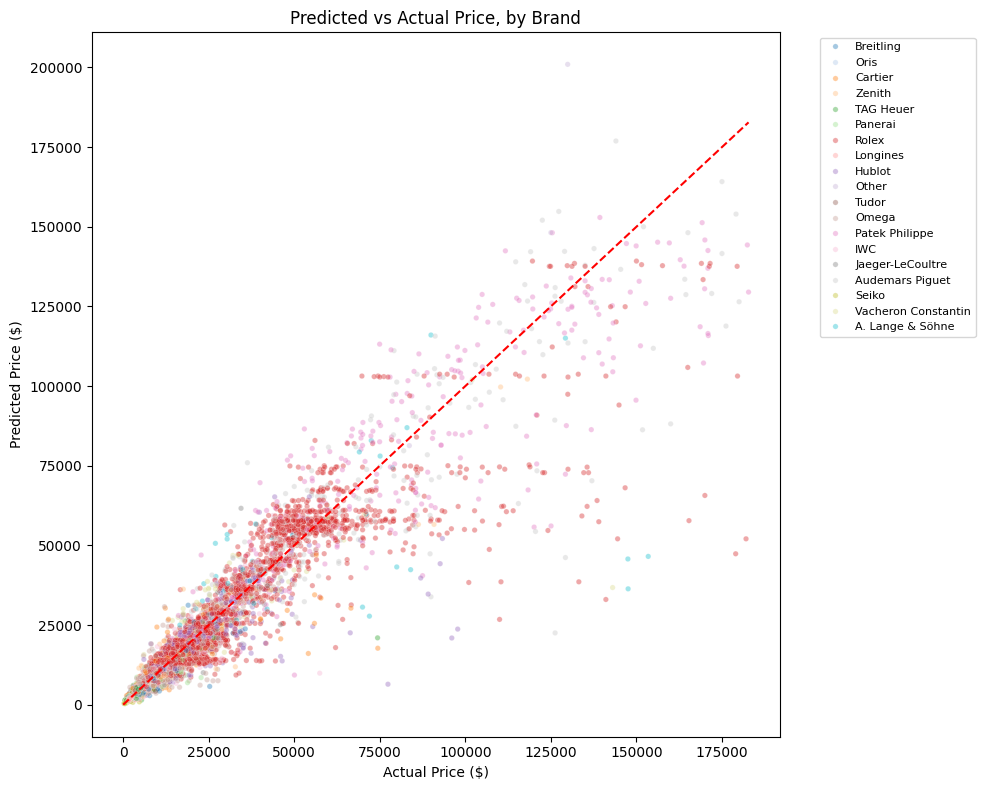

                     abs_pct_error
actual                            
(346.999, 4089.4]        17.839316
(4089.4, 7700.2]         15.315652
(7700.2, 13838.0]        16.963206
(13838.0, 25757.8]       14.403980
(25757.8, 182766.0]      18.371022

Overall median % error: 12.1%


In [239]:
# @title
residuals_df = pd.DataFrame({
    'actual': y_test_actual,
    'predicted': y_pred_actual,
    'error': y_pred_actual - y_test_actual,
    'abs_pct_error': np.abs((y_pred_actual - y_test_actual) / y_test_actual) * 100
})
residuals_df['brand'] = new_df.loc[X_test.index, 'brand'].values

plt.figure(figsize=(10, 8))
sns.scatterplot(data=residuals_df, x='actual', y='predicted', hue='brand', alpha=0.4, s=15, palette='tab20')
max_val = residuals_df['actual'].max()
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Predicted vs Actual Price, by Brand')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

price_bins = pd.qcut(residuals_df['actual'], q=5)
print(residuals_df.groupby(price_bins)[['abs_pct_error']].mean())
print(f"\nOverall median % error: {residuals_df['abs_pct_error'].median():.1f}%")

## **Final model**

In [240]:
# @title
perm_threshold = 0.001

final_features = perm_importance[perm_importance > perm_threshold].index.tolist()
dropped_features = perm_importance[perm_importance <= perm_threshold].index.tolist()

print(f"Features kept ({len(final_features)}): {final_features}")
print(f"\nFeatures dropped ({len(dropped_features)}): {dropped_features}")

X_train_final = X_train[final_features]
X_test_final = X_test[final_features]

category_cols_final = [c for c in category_cols if c in final_features]

final_model = lgb.LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_train_final, y_train,
    eval_set=[(X_test_final, y_test)],
    categorical_feature=category_cols_final,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(50)]
)

y_pred_log_final = final_model.predict(X_test_final)

rmse_log_final = np.sqrt(mean_squared_error(y_test, y_pred_log_final))
mae_log_final = mean_absolute_error(y_test, y_pred_log_final)
r2_final = r2_score(y_test, y_pred_log_final)

y_pred_actual_final = np.expm1(y_pred_log_final)
rmse_actual_final = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual_final))
mae_actual_final = mean_absolute_error(y_test_actual, y_pred_actual_final)

mape_log_final = np.mean(np.abs((y_test - y_pred_log_final) / y_test)) * 100
mape_final = np.mean(np.abs((y_test_actual - y_pred_actual_final) / y_test_actual)) * 100

print(f"\n--- Final model ({len(final_features)} features) ---")
print(f"RMSE (log): {rmse_log_final:.4f}")
print(f"MAE (log): {mae_log_final:.4f}")
print(f"MAPE (log): {mape_log_final:.2f}%")
print(f"R²: {r2_final:.4f}")
print(f"RMSE ($): ${rmse_actual_final:,.0f}")
print(f"MAE ($): ${mae_actual_final:,.0f}")
print(f"MAPE ($): {mape_final:.2f}%")

Features kept (10): ['model_prefix_median_price', 'casem', 'brand', 'ref_prefix', 'condition_score', 'watch_age', 'mvmt', 'size_mm', 'bracem', 'precious_case']

Features dropped (12): ['has_limited', 'sex', 'precious_brace', 'same_material', 'name_len_bucket', 'has_wealthy_words', 'has_papers', 'color_lightness', 'color_hue_cos', 'name_missing', 'color_hue_sin', 'color_has_hue']
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001338 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1369
[LightGBM] [Info] Number of data points in the train set: 39353, number of used features: 10
[LightGBM] [Info] Start training f

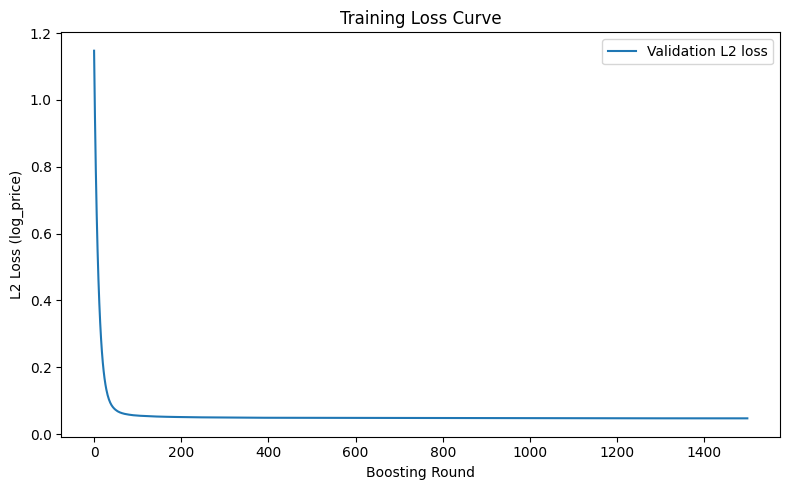

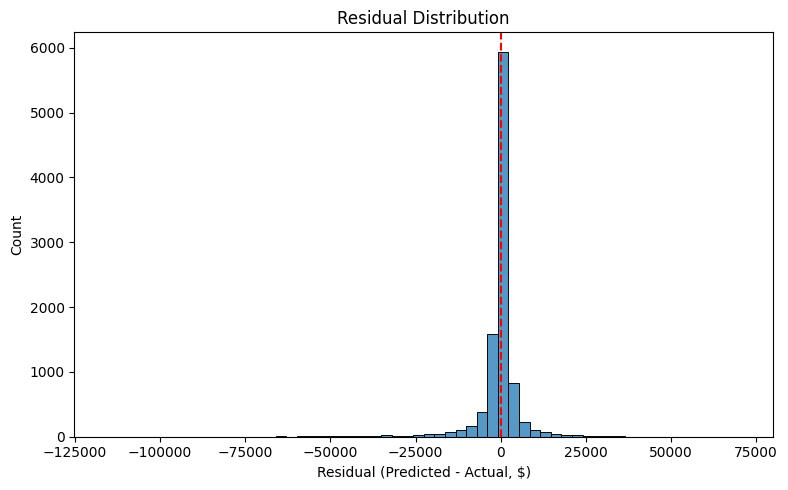

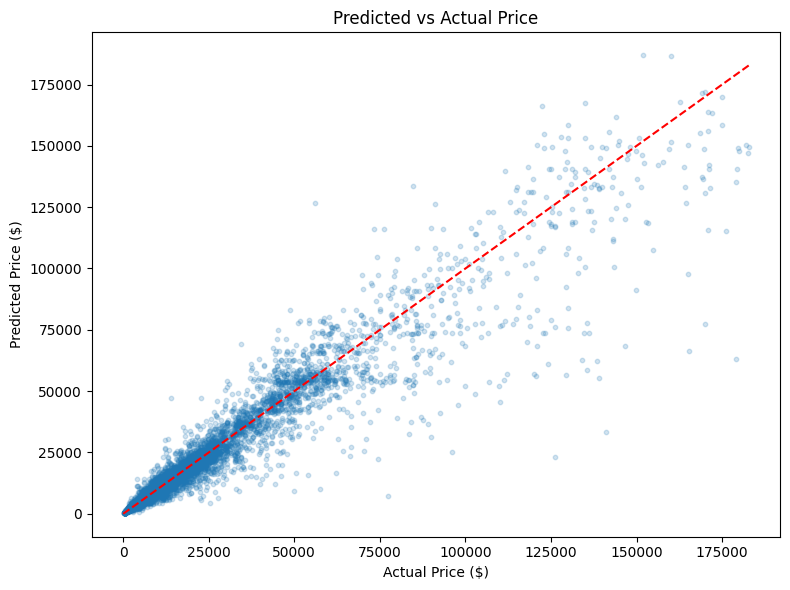

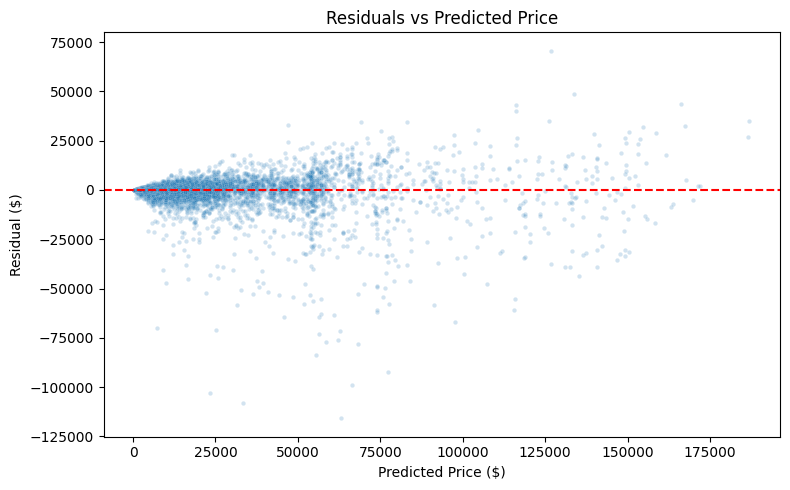

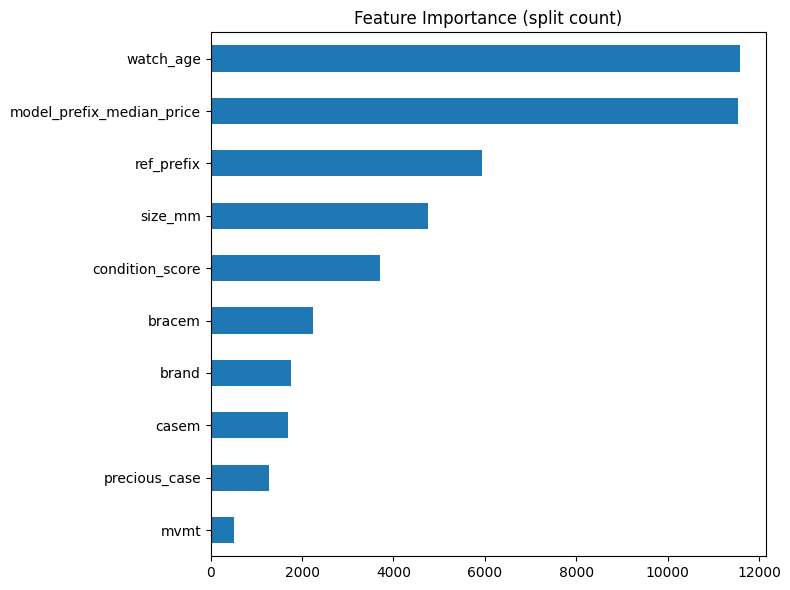

In [241]:
# @title
eval_results = final_model.evals_result_

plt.figure(figsize=(8, 5))
plt.plot(eval_results['valid_0']['l2'], label='Validation L2 loss')
plt.xlabel('Boosting Round')
plt.ylabel('L2 Loss (log_price)')
plt.title('Training Loss Curve')
plt.legend()
plt.tight_layout()
plt.show()

residuals = y_pred_actual_final - y_test_actual

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=60)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Residual (Predicted - Actual, $)')
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(y_test_actual, y_pred_actual_final, alpha=0.2, s=10)
max_val = y_test_actual.max()
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Predicted vs Actual Price')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_actual_final, y=residuals, alpha=0.2, s=10)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residual ($)')
plt.title('Residuals vs Predicted Price')
plt.tight_layout()
plt.show()

importances = pd.Series(final_model.feature_importances_, index=final_features).sort_values()
plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.title('Feature Importance (split count)')
plt.tight_layout()
plt.show()

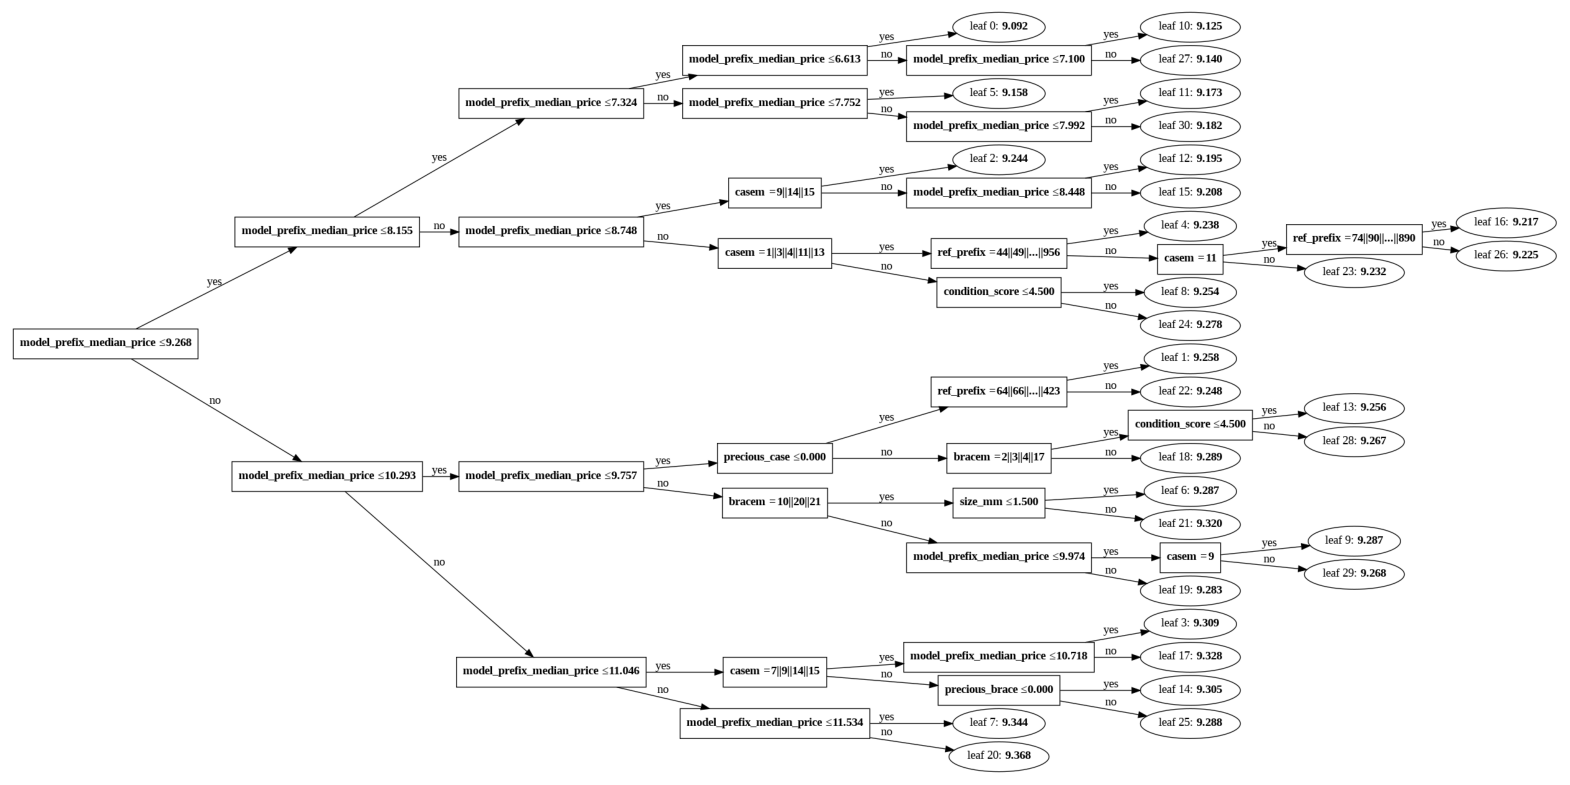

In [225]:
lgb.plot_tree(final_model.booster_, tree_index=0, figsize=(20, 10))
plt.show()

# Post-prediction Analitics

In [242]:
# @title
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

low, high = iqr_bounds(residuals_df['abs_pct_error'])
outliers = residuals_df[residuals_df['abs_pct_error'] > high].copy()

print(f"Outlier bounds (IQR): abs_pct_error > {high:.1f}%")
print(f"Number of outlier predictions: {len(outliers)}")
print(f"Percentage of test set: {len(outliers) / len(residuals_df) * 100:.2f}%")

display_cols = ['actual', 'predicted', 'error', 'abs_pct_error', 'brand']
extra_cols = ['casem', 'bracem', 'mvmt', 'condition', 'watch_age', 'size_mm']

for col in extra_cols:
    if col not in outliers.columns:
        outliers[col] = new_df.loc[outliers.index, col].values

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

outliers_sorted = outliers.sort_values('abs_pct_error', ascending=False)
print(f"\nAll {len(outliers_sorted)} outlier predictions:")
print(outliers_sorted[display_cols + extra_cols].round(1))

Outlier bounds (IQR): abs_pct_error > 48.7%
Number of outlier predictions: 430
Percentage of test set: 4.37%

All 430 outlier predictions:
         actual  predicted    error  abs_pct_error                brand  \
257598    518.0     1498.8    980.8          189.4            TAG Heuer   
45639    1000.0     2857.2   1857.2          185.7              Cartier   
122944   1966.0     5451.1   3485.1          177.3                Omega   
276557   6042.0    15724.7   9682.7          160.3  Vacheron Constantin   
92938    5938.0    15362.5   9424.5          158.7                Omega   
...         ...        ...      ...            ...                  ...   
180074  45140.0    23087.8 -22052.2           48.9                Rolex   
193430  33500.0    17143.6 -16356.4           48.8                Rolex   
93727   17672.0     9046.4  -8625.6           48.8                Omega   
36282    4509.0     6708.2   2199.2           48.8              Cartier   
70411   10950.0    16289.4   5339.4 

In [243]:
residuals_df['brand'] = new_df.loc[X_test.index, 'brand'].values
print(residuals_df.groupby('brand')['abs_pct_error'].mean().sort_values(ascending=False))

brand
Other                  37.509710
A. Lange & Söhne       31.916475
Vacheron Constantin    26.343252
Cartier                20.887852
Zenith                 20.398427
Omega                  19.548445
Patek Philippe         18.708054
Hublot                 18.429248
Jaeger-LeCoultre       18.344818
Audemars Piguet        18.302951
IWC                    18.153855
Seiko                  17.056794
TAG Heuer              16.682170
Tudor                  16.057551
Longines               15.550090
Rolex                  15.034853
Panerai                14.982456
Oris                   13.700378
Breitling              12.344531
Name: abs_pct_error, dtype: float64


In [244]:
# @title
worst_10 = residuals_df.nlargest(10, 'abs_pct_error')

display_cols = ['actual', 'predicted', 'error', 'abs_pct_error', 'brand']
extra_cols = ['casem', 'bracem', 'mvmt', 'condition', 'watch_age', 'size_mm']

for col in extra_cols:
    if col not in worst_10.columns:
        worst_10[col] = new_df.loc[worst_10.index, col].values

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(worst_10[display_cols + extra_cols].round(1))

         actual  predicted    error  abs_pct_error                brand  \
257598    518.0     1498.8    980.8          189.4            TAG Heuer   
45639    1000.0     2857.2   1857.2          185.7              Cartier   
122944   1966.0     5451.1   3485.1          177.3                Omega   
276557   6042.0    15724.7   9682.7          160.3  Vacheron Constantin   
92938    5938.0    15362.5   9424.5          158.7                Omega   
92693   12085.0    30767.6  18682.6          154.6                Omega   
279534   4601.0    11464.0   6863.0          149.2               Zenith   
44898    9850.0    24366.9  14516.9          147.4              Cartier   
44686   12300.0    30301.8  18001.8          146.4              Cartier   
50625    8074.0    19127.3  11053.3          136.9               Hublot   

              casem          bracem            mvmt  condition  watch_age  \
257598        Steel           Steel          Quartz  Very good       30.0   
45639    Gold/Steel 


--- Worst #1 | TAG Heuer actual=$518, predicted=$1,499, error=189% ---


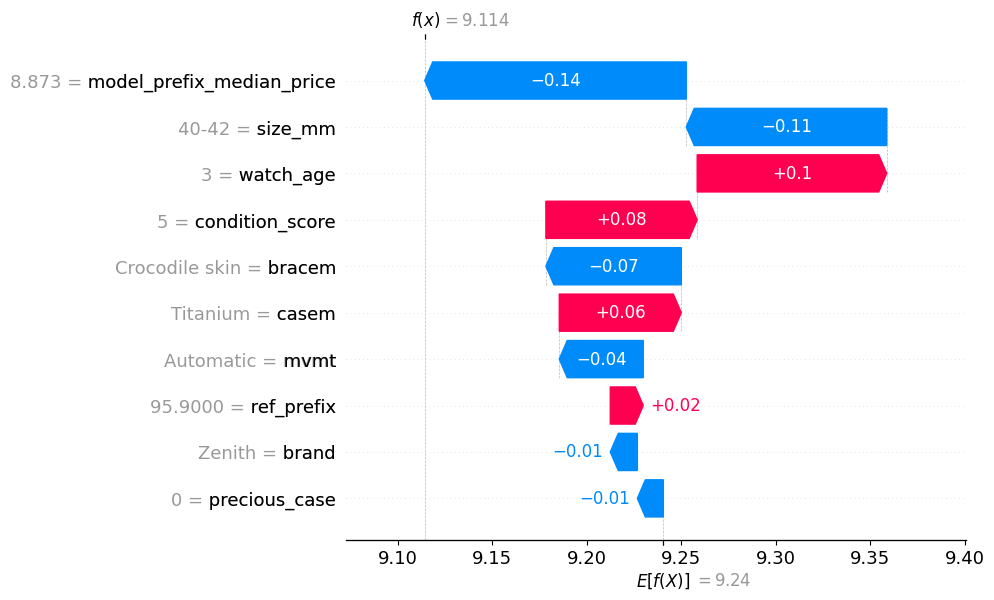


--- Worst #2 | Cartier actual=$1,000, predicted=$2,857, error=186% ---


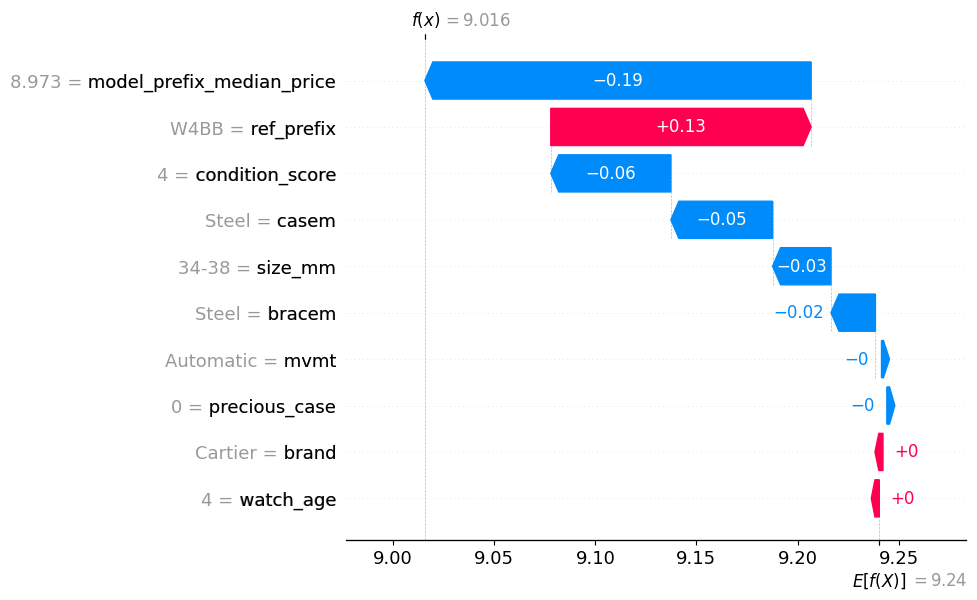


--- Worst #3 | Omega actual=$1,966, predicted=$5,451, error=177% ---


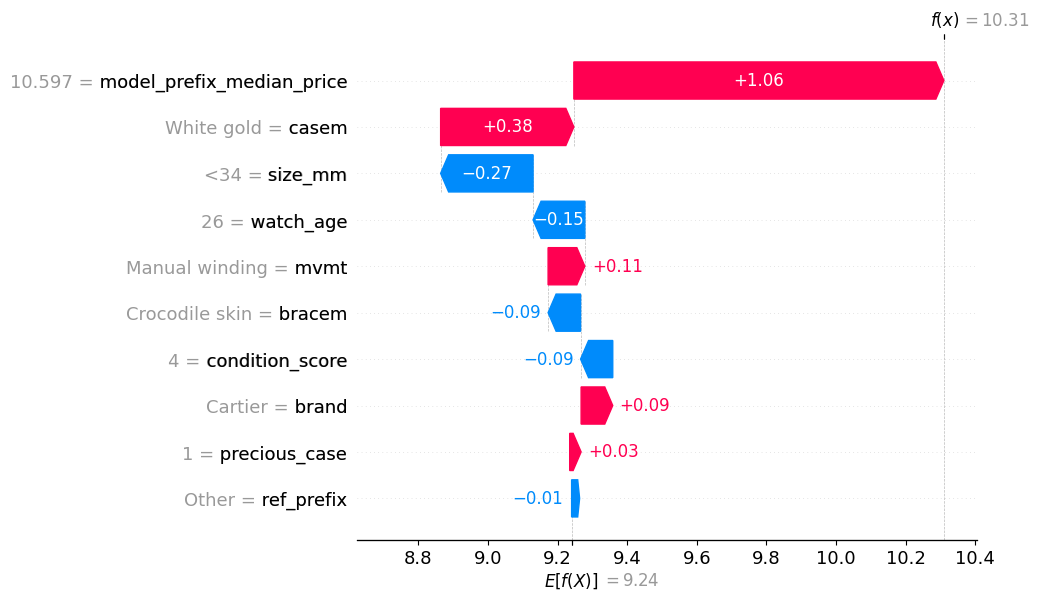


--- Worst #4 | Vacheron Constantin actual=$6,042, predicted=$15,725, error=160% ---


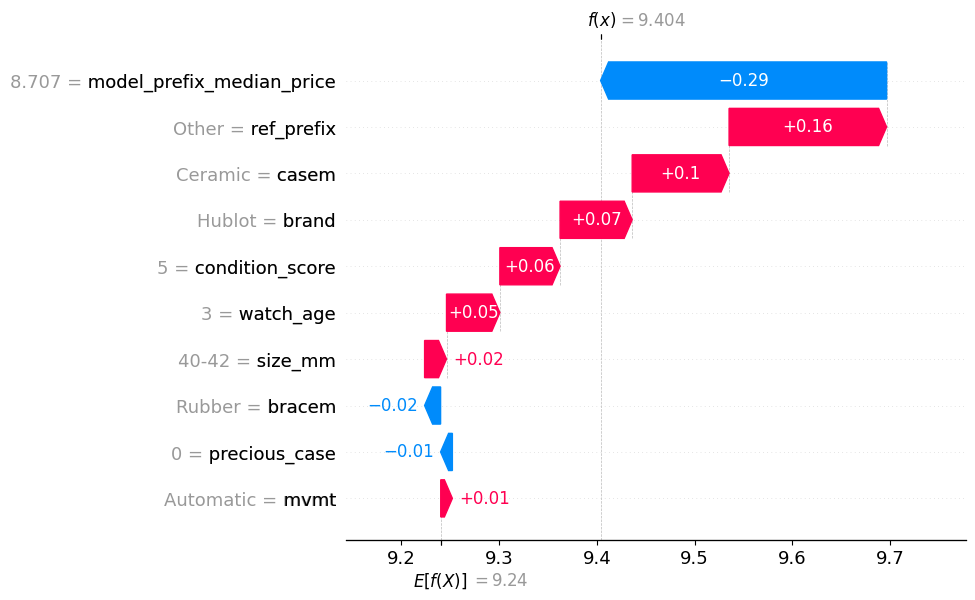

In [245]:
# @title
worst_10 = residuals_df.nlargest(10, 'abs_pct_error')
worst_positions = [X_test_final.index.get_loc(idx) for idx in worst_10.index][6:]

import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer(X_test_final)

for i, pos in enumerate(worst_positions):
    idx = worst_10.index[i]
    print(f"\n--- Worst #{i+1} | {worst_10.loc[idx, 'brand']} actual=${worst_10.loc[idx, 'actual']:,.0f}, predicted=${worst_10.loc[idx, 'predicted']:,.0f}, error={worst_10.loc[idx, 'abs_pct_error']:.0f}% ---")
    shap.plots.waterfall(shap_values[pos])

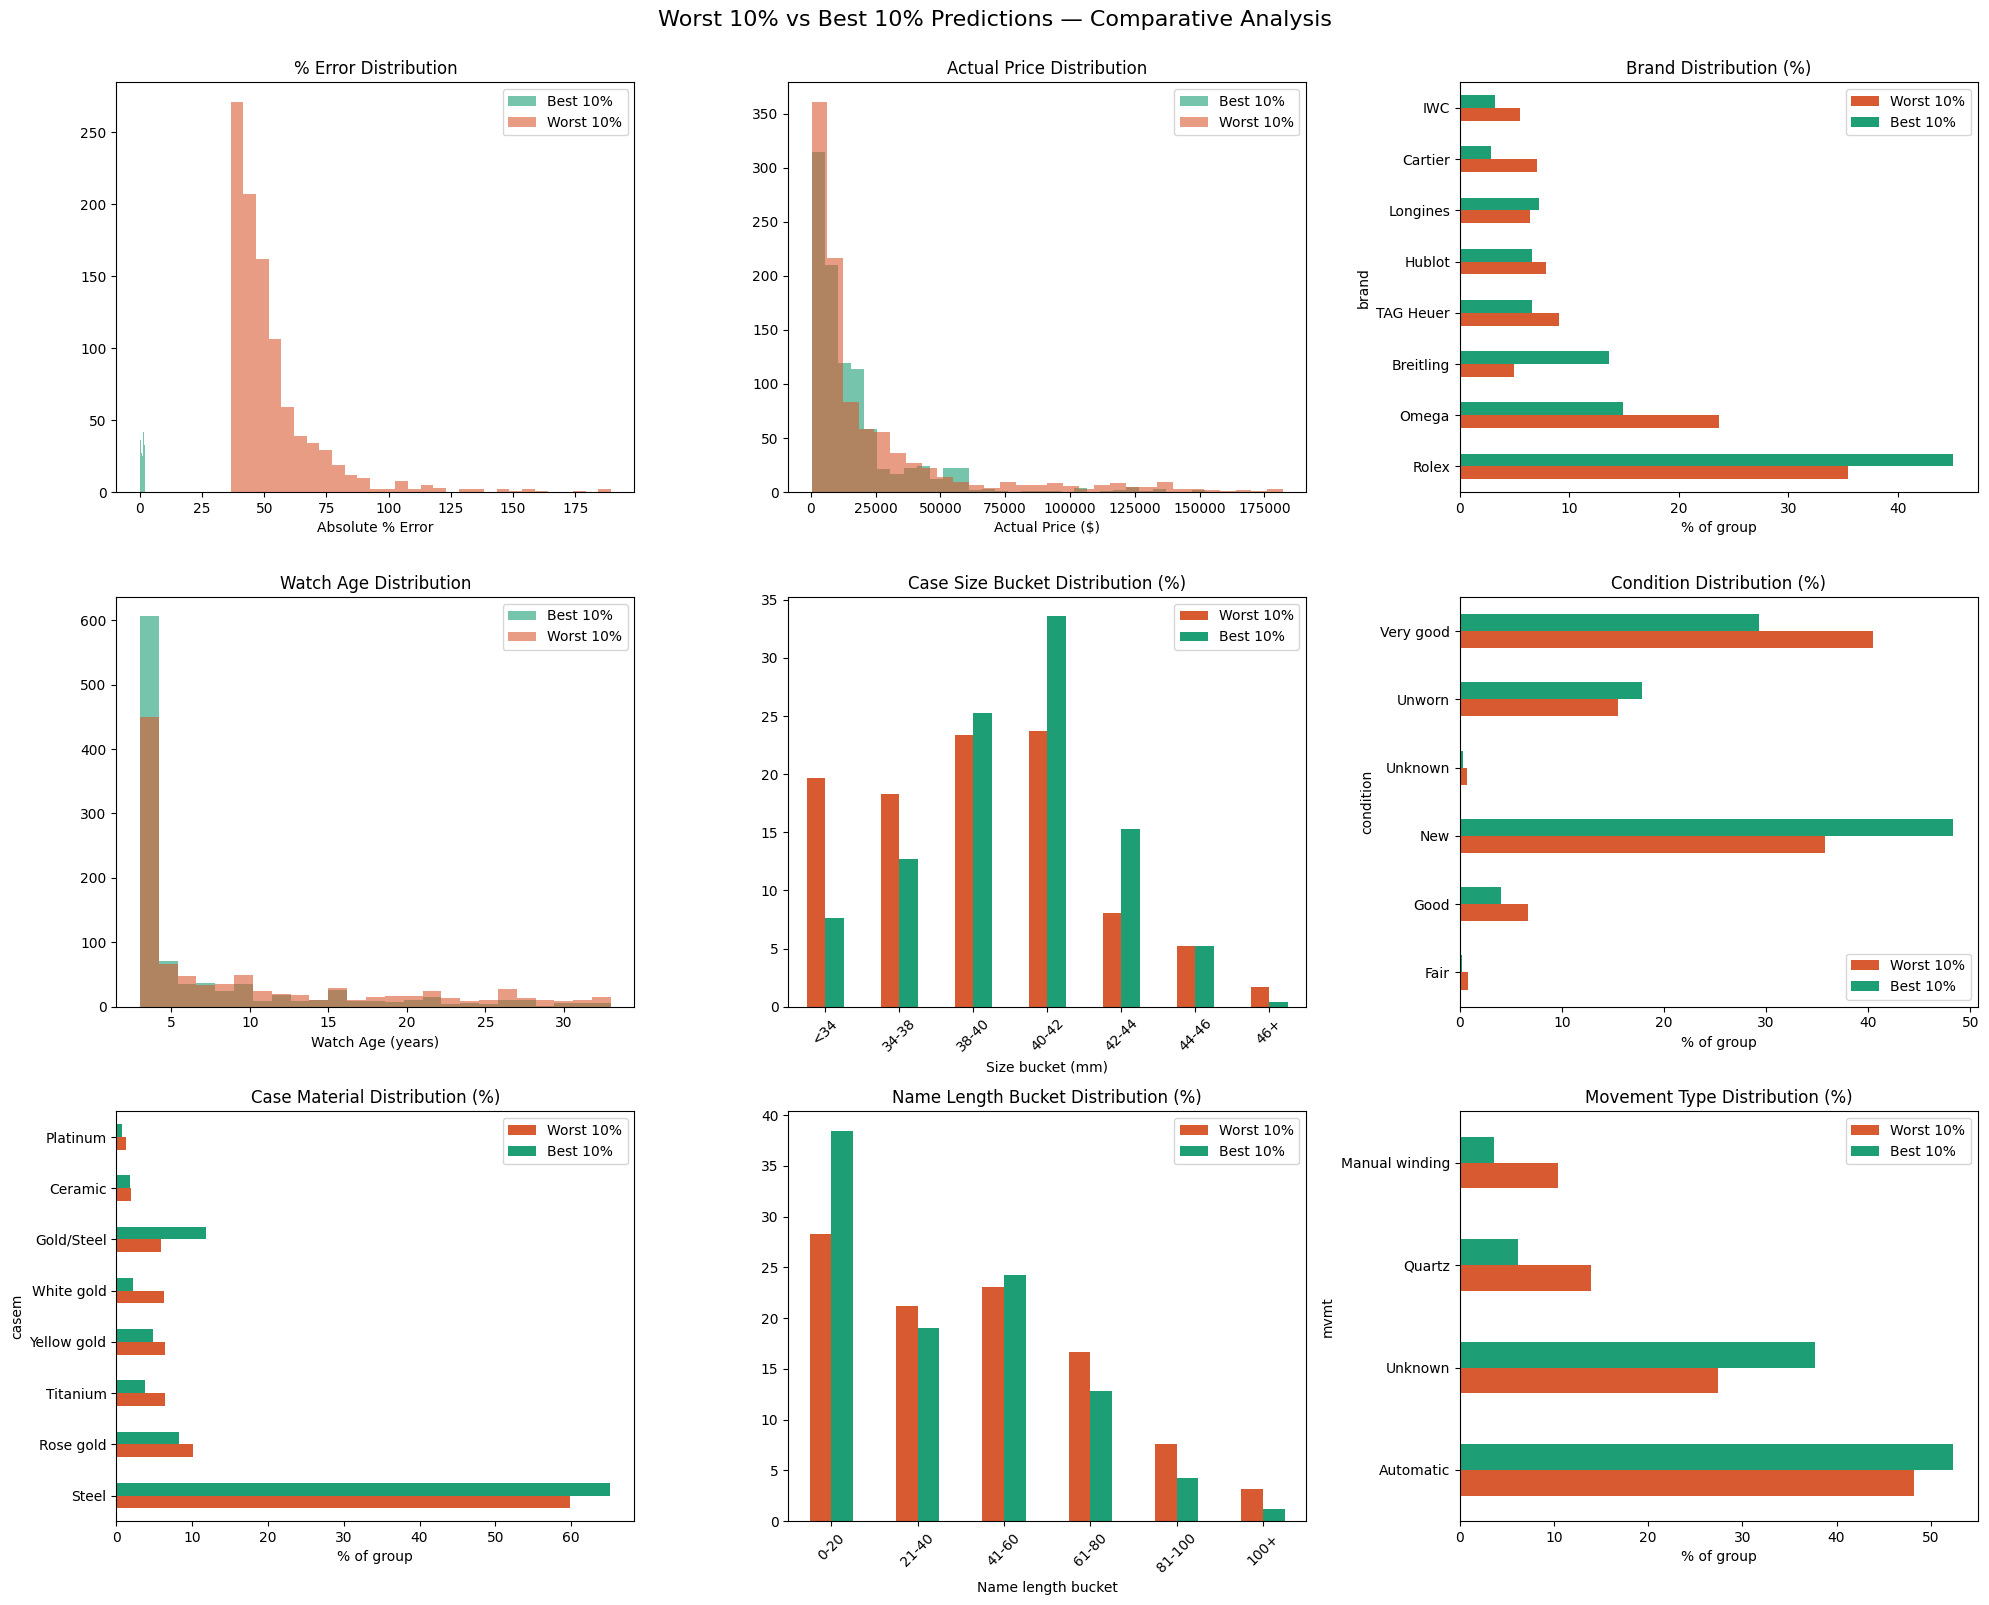

                      Worst 10%  Best 10%
Mean Price ($)          23044.2   16832.2
Mean Age (yrs)              9.4       6.8
Mean Condition Score        4.6       4.8
Median % Error             47.0       0.9


In [246]:
# @title
worst_n = int(len(residuals_df) * 0.10)
worst = residuals_df.nlargest(worst_n, 'abs_pct_error').copy()
best = residuals_df.nsmallest(worst_n, 'abs_pct_error').copy()

for col in ['casem', 'bracem', 'mvmt', 'condition', 'watch_age', 'size_mm', 'condition_score', 'name_len_bucket']:
    if col not in worst.columns:
        worst[col] = new_df.loc[worst.index, col].values
        best[col] = new_df.loc[best.index, col].values

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle('Worst 10% vs Best 10% Predictions — Comparative Analysis', fontsize=16, y=1.00)

axes[0, 0].hist(best['abs_pct_error'], bins=30, alpha=0.6, label='Best 10%', color='#1D9E75')
axes[0, 0].hist(worst['abs_pct_error'], bins=30, alpha=0.6, label='Worst 10%', color='#D85A30')
axes[0, 0].set_title('% Error Distribution')
axes[0, 0].set_xlabel('Absolute % Error')
axes[0, 0].legend()

axes[0, 1].hist(best['actual'], bins=30, alpha=0.6, label='Best 10%', color='#1D9E75')
axes[0, 1].hist(worst['actual'], bins=30, alpha=0.6, label='Worst 10%', color='#D85A30')
axes[0, 1].set_title('Actual Price Distribution')
axes[0, 1].set_xlabel('Actual Price ($)')
axes[0, 1].legend()

top_brands = pd.concat([worst['brand'], best['brand']]).value_counts().head(8).index
brand_compare = pd.DataFrame({
    'Worst 10%': worst[worst['brand'].isin(top_brands)]['brand'].value_counts(normalize=True) * 100,
    'Best 10%': best[best['brand'].isin(top_brands)]['brand'].value_counts(normalize=True) * 100
}).reindex(top_brands).fillna(0)
brand_compare.plot(kind='barh', ax=axes[0, 2], color=['#D85A30', '#1D9E75'])
axes[0, 2].set_title('Brand Distribution (%)')
axes[0, 2].set_xlabel('% of group')

axes[1, 0].hist(best['watch_age'], bins=25, alpha=0.6, label='Best 10%', color='#1D9E75')
axes[1, 0].hist(worst['watch_age'], bins=25, alpha=0.6, label='Worst 10%', color='#D85A30')
axes[1, 0].set_title('Watch Age Distribution')
axes[1, 0].set_xlabel('Watch Age (years)')
axes[1, 0].legend()

size_order = ['<34', '34-38', '38-40', '40-42', '42-44', '44-46', '46+']
size_compare = pd.DataFrame({
    'Worst 10%': worst['size_mm'].value_counts(normalize=True) * 100,
    'Best 10%': best['size_mm'].value_counts(normalize=True) * 100
}).reindex(size_order).fillna(0)
size_compare.plot(kind='bar', ax=axes[1, 1], color=['#D85A30', '#1D9E75'])
axes[1, 1].set_title('Case Size Bucket Distribution (%)')
axes[1, 1].set_xlabel('Size bucket (mm)')
axes[1, 1].tick_params(axis='x', rotation=45)

condition_compare = pd.DataFrame({
    'Worst 10%': worst['condition'].value_counts(normalize=True) * 100,
    'Best 10%': best['condition'].value_counts(normalize=True) * 100
}).fillna(0)
condition_compare.plot(kind='barh', ax=axes[1, 2], color=['#D85A30', '#1D9E75'])
axes[1, 2].set_title('Condition Distribution (%)')
axes[1, 2].set_xlabel('% of group')

casem_compare = pd.DataFrame({
    'Worst 10%': worst['casem'].value_counts(normalize=True) * 100,
    'Best 10%': best['casem'].value_counts(normalize=True) * 100
}).fillna(0).sort_values('Worst 10%', ascending=False).head(8)
casem_compare.plot(kind='barh', ax=axes[2, 0], color=['#D85A30', '#1D9E75'])
axes[2, 0].set_title('Case Material Distribution (%)')
axes[2, 0].set_xlabel('% of group')

name_len_order = ['0-20', '21-40', '41-60', '61-80', '81-100', '100+']
name_len_compare = pd.DataFrame({
    'Worst 10%': worst['name_len_bucket'].value_counts(normalize=True) * 100,
    'Best 10%': best['name_len_bucket'].value_counts(normalize=True) * 100
}).reindex(name_len_order).fillna(0)
name_len_compare.plot(kind='bar', ax=axes[2, 1], color=['#D85A30', '#1D9E75'])
axes[2, 1].set_title('Name Length Bucket Distribution (%)')
axes[2, 1].set_xlabel('Name length bucket')
axes[2, 1].tick_params(axis='x', rotation=45)

mvmt_compare = pd.DataFrame({
    'Worst 10%': worst['mvmt'].value_counts(normalize=True) * 100,
    'Best 10%': best['mvmt'].value_counts(normalize=True) * 100
}).fillna(0)
mvmt_compare.plot(kind='barh', ax=axes[2, 2], color=['#D85A30', '#1D9E75'])
axes[2, 2].set_title('Movement Type Distribution (%)')
axes[2, 2].set_xlabel('% of group')

plt.tight_layout()
plt.show()

summary_stats = pd.DataFrame({
    'Worst 10%': [worst['actual'].mean(), worst['watch_age'].mean(), worst['condition_score'].mean(), worst['abs_pct_error'].median()],
    'Best 10%': [best['actual'].mean(), best['watch_age'].mean(), best['condition_score'].mean(), best['abs_pct_error'].median()]
}, index=['Mean Price ($)', 'Mean Age (yrs)', 'Mean Condition Score', 'Median % Error'])

print(summary_stats.round(1))

In [247]:
seiko = new_df[new_df['brand'] == 'Seiko'].copy()
prospex = seiko[seiko['model'] == 'Prospex'].sort_values('price')

pd.set_option('display.max_colwidth', None)

print("=== CHEAPEST 10 Prospex ===")
print(prospex[['price', 'ref', 'name']].head(10).to_string())

print("\n=== MOST EXPENSIVE 10 Prospex ===")
print(prospex[['price', 'ref', 'name']].tail(10).to_string())

print(f"\n=== Ref prefix vs price (Seiko) ===")
seiko['ref_prefix'] = seiko['ref'].str.extract(r'^([A-Z]+)')[0]
print(seiko.groupby('ref_prefix')['price'].agg(['count', 'median', 'min', 'max']).sort_values('median', ascending=False).head(15))

=== CHEAPEST 10 Prospex ===
        price       ref                                                                                           name
226367  348.0  SRPG15K1      Seiko Prospex\nLand Tortoise Series Automatic Watch SBDY101 / SRPG15K1 with 1 yr warranty
233831  348.0   SBDJ053                 Seiko Prospex\nSolar Men's Watch Black Dial Pepsi Color Bezel SBDJ053/SNE591P1
226368  352.0  SRPD27K1                           Seiko Prospex\nMonster Automatic watch SRPD27K1 With 1 year warranty
234377  354.0  SNE575P1                                                    Seiko Prospex\nSNE575P PADI Solar Air Diver
226373  366.0  SRPD46K1   Seiko Prospex\nBlack Gold "Turtle" Diver Scuba Automatic Watch SRPD46K1 With 1 year warranty
226372  366.0  SRP787K1  Seiko Prospex\nTurtle diver Automatic Mechanical watch SRP787K1 SRPF15K1 with 1 year warranty
231397  374.0   SBDY021                                   Seiko Prospex\nDiver SBDY021 / SRPC91J1 with 1 year warranty
226377  379.0  SRPE2

In [248]:
extreme = worst[worst['abs_pct_error'] > 200]
print(extreme[['actual', 'predicted', 'abs_pct_error', 'brand', 'casem', 'bracem', 'mvmt', 'condition', 'watch_age', 'size_mm']])

Empty DataFrame
Columns: [actual, predicted, abs_pct_error, brand, casem, bracem, mvmt, condition, watch_age, size_mm]
Index: []


Total Seiko rows in test set: 193

Seiko price stats:
count     193.000000
mean     1225.233161
std      1230.826176
min       347.000000
25%       495.000000
50%       684.000000
75%      1369.000000
max      6215.000000
Name: price, dtype: float64

Seiko median % error: 12.1%
Overall median % error: 12.1%


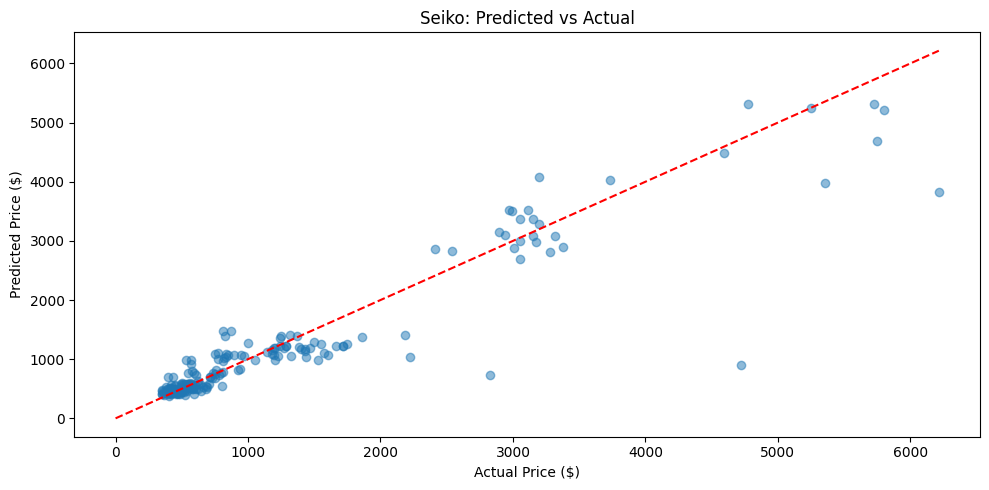


Seiko model distribution:
model
Prospex             104
Presage              48
5 Sports             23
Alpinist              7
Unknown               4
5                     2
Chronograph           1
Astron                1
Astron GPS Solar      1
King                  1
Marinemaster          1
Name: count, dtype: int64

Seiko price range by model (top 10 models):
Prospex: n=104, price range $396-$6215, median $1162
Presage: n=48, price range $347-$3278, median $554
5 Sports: n=23, price range $348-$684, median $447
Alpinist: n=7, price range $495-$2828, median $730
Unknown: n=4, price range $432-$939, median $758
5: n=2, price range $349-$459, median $404
Chronograph: n=1, price range $454-$454, median $454
Astron: n=1, price range $814-$814, median $814
Astron GPS Solar: n=1, price range $1604-$1604, median $1604
King: n=1, price range $2540-$2540, median $2540

Seiko casem distribution:
casem
Steel       183
Titanium     10
Name: count, dtype: int64

Seiko condition distribution:
c

In [249]:
# @title
seiko_test = new_df.loc[X_test_final.index][new_df.loc[X_test_final.index, 'brand'] == 'Seiko']
seiko_residuals = residuals_df.loc[residuals_df.index.intersection(seiko_test.index)]

print(f"Total Seiko rows in test set: {len(seiko_residuals)}")
print(f"\nSeiko price stats:\n{seiko_test['price'].describe()}")

print(f"\nSeiko median % error: {seiko_residuals['abs_pct_error'].median():.1f}%")
print(f"Overall median % error: {residuals_df['abs_pct_error'].median():.1f}%")

plt.figure(figsize=(10, 5))
plt.scatter(seiko_residuals['actual'], seiko_residuals['predicted'], alpha=0.5)
max_val = max(seiko_residuals['actual'].max(), seiko_residuals['predicted'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Seiko: Predicted vs Actual')
plt.tight_layout()
plt.show()

print(f"\nSeiko model distribution:\n{seiko_test['model'].value_counts().head(15)}")

print(f"\nSeiko price range by model (top 10 models):")
top_models = seiko_test['model'].value_counts().head(10).index
for m in top_models:
    subset = seiko_test[seiko_test['model'] == m]
    print(f"{m}: n={len(subset)}, price range ${subset['price'].min():.0f}-${subset['price'].max():.0f}, median ${subset['price'].median():.0f}")

print(f"\nSeiko casem distribution:\n{seiko_test['casem'].value_counts()}")
print(f"\nSeiko condition distribution:\n{seiko_test['condition'].value_counts()}")

In [250]:
pd.set_option('display.max_colwidth', None)

examples = new_df.dropna(subset=['ref']).groupby('brand')['ref'].first()
print(examples.to_string())

brand
A. Lange & Söhne                              192.029
Audemars Piguet                  26715ST.OO.1356ST.01
Breitling                               A45330101C1X4
Cartier                                      WSSA0037
Hublot                           418.OX.2001.RX.MXM20
IWC                                          IW377725
Jaeger-LeCoultre                             Q2518540
Longines                                    L33744500
Omega                             212.30.41.20.01.003
Oris                   01 733 7730 4157-07 8 24 05PEB
Other                                             142
Panerai                                      PAM01274
Patek Philippe                            7118/1A-010
Rolex                                          124300
Seiko                                         SDKA001
TAG Heuer                              WBD2320.BA0740
Tudor                                           79280
Vacheron Constantin                   81180/000R-B518
Zenith                

In [251]:
counts = new_df['brand_model_prefix'].value_counts()
sizes = new_df['brand_model_prefix'].map(counts)
print(f"Groups: {new_df['brand_model_prefix'].nunique()}")
print(f"Median group size: {sizes.median():.0f}")
print(f"Rows in groups of 3-5: {((sizes>=3)&(sizes<=5)).mean()*100:.1f}%")
print(f"Rows in groups of 20+: {(sizes>=20).mean()*100:.1f}%")

Groups: 2605
Median group size: 65
Rows in groups of 3-5: 4.5%
Rows in groups of 20+: 76.2%
